# D53G1U – Gépi tanulás házi feladat

In [89]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, SGDClassifier

from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 700664640

## 1. rész – Generált klasszifikációs adathalmaz

Klasszifikációs adathalmaz generálás, vizsgált algoritmusok: Naive Bayes, Random Forest és K-Nearest Neighbors.

In [90]:
X, y = make_classification(
    n_samples=240,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    n_clusters_per_class=1,
    flip_y=0.01,
    class_sep=1.0,
    random_state=RANDOM_STATE,
)

print('X alakja:', X.shape)
print('y alakja:', y.shape)
print('Osztályeloszlás:', np.bincount(y))

X alakja: (240, 10)
y alakja: (240,)
Osztályeloszlás: [120 120]


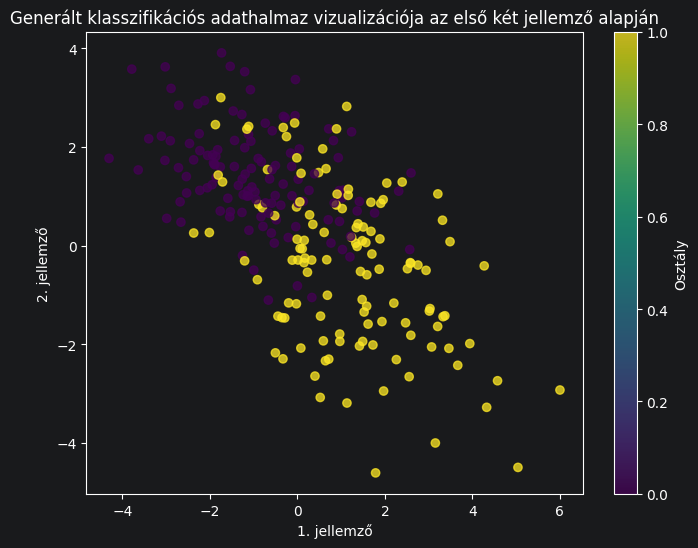

In [91]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.75)
plt.xlabel("1. jellemző")
plt.ylabel("2. jellemző")
plt.title("Generált klasszifikációs adathalmaz vizualizációja az első két jellemző alapján")
plt.colorbar(label="Osztály")
plt.show()

### Tanító és teszt adathalmaz szétválasztása

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print('Tanító minták:', X_train.shape[0])
print('Teszt minták:', X_test.shape[0])

Tanító minták: 180
Teszt minták: 60


### Modellek és hiperparaméter-hangolás

In [93]:
classification_models = {
    'Naive Bayes': (GaussianNB(), {'var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8, 1e-7]}),
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [50, 100, 200], 'max_depth': [None, 3, 5, 10]},
    ),
    'K-Nearest Neighbors': (
        Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
        {'knn__n_neighbors': [3, 5, 7, 9], 'knn__weights': ['uniform', 'distance']},
    ),
}

classification_results = []
best_classification_models = {}

for name, (model, params) in classification_models.items():
    start = time.perf_counter()
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    best_model = grid.best_estimator_
    best_classification_models[name] = best_model

    train_pred = best_model.predict(X_train)
    test_pred = best_model.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    classification_results.append({
        'Algoritmus': name,
        'Tanítási pontosság': train_acc,
        'Teszt pontosság': test_acc,
        'Tanítási hiba': 1 - train_acc,
        'Teszt hiba': 1 - test_acc,
        'Tanítási idő [s]': fit_time,
        'Legjobb paraméterek': grid.best_params_,
    })

classification_results_df = pd.DataFrame(classification_results)
classification_results_df

,Algoritmus,Tanítási pontosság,Teszt pontosság,Tanítási hiba,Teszt hiba,Tanítási idő [s],Legjobb paraméterek
0,Naive Bayes,0.927778,0.916667,0.072222,0.083333,1.235363,{'var_smoothing': 1e-12}
1,Random Forest,1.000000,0.933333,0.000000,0.066667,0.826916,"{'max_depth': None, 'n_estimators': 100}"
2,K-Nearest Neighbors,0.972222,0.916667,0.027778,0.083333,0.027768,"{'knn__n_neighbors': 3, 'knn__weights': 'unifo..."


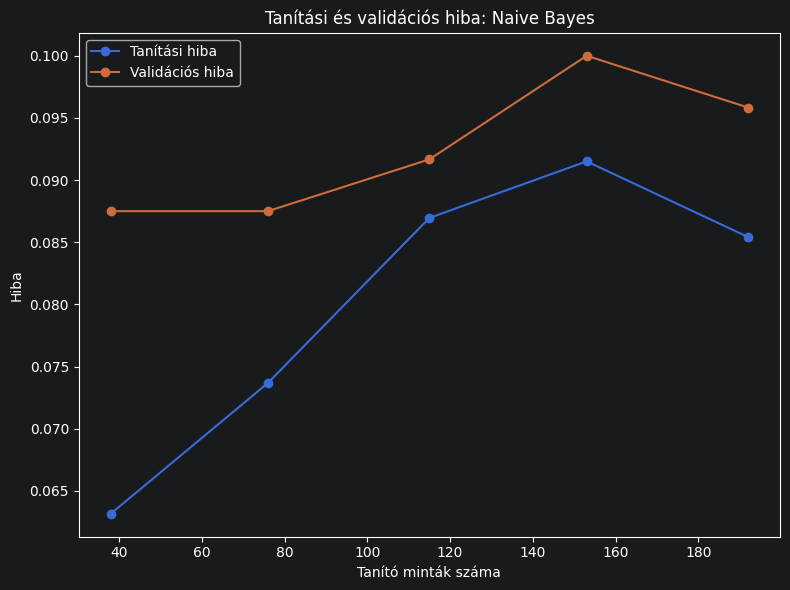

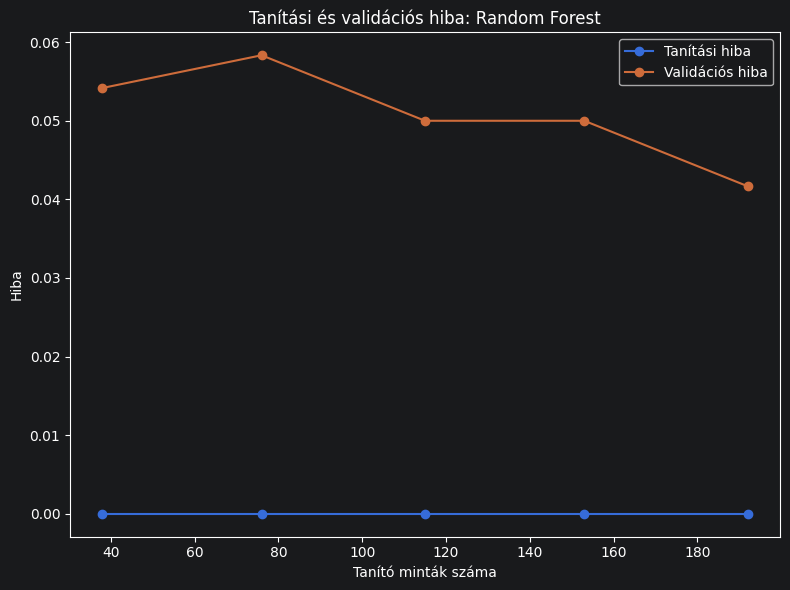

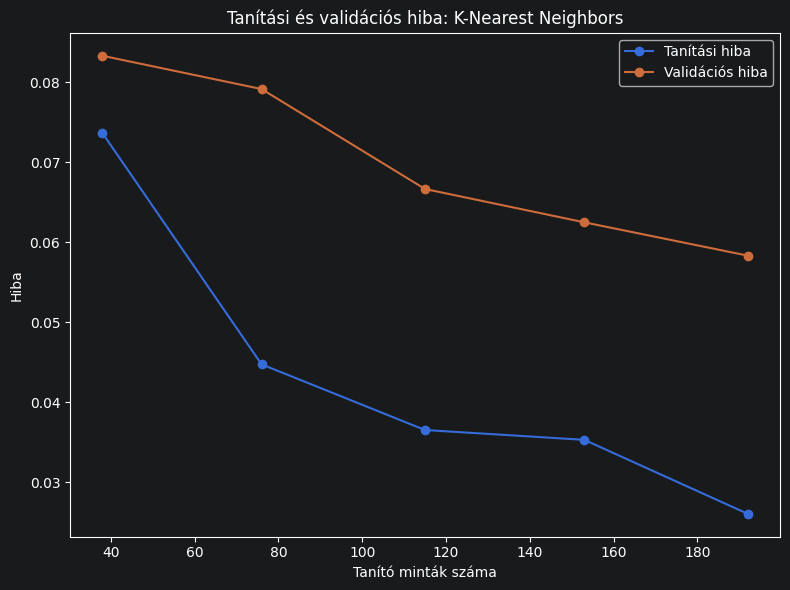

In [94]:
for name, model in best_classification_models.items():
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1
    )
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, 1 - train_scores.mean(axis=1), marker='o', label='Tanítási hiba')
    plt.plot(train_sizes, 1 - test_scores.mean(axis=1), marker='o', label='Validációs hiba')
    plt.xlabel('Tanító minták száma')
    plt.ylabel('Hiba')
    plt.title(f'Tanítási és validációs hiba: {name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Learning rate és epoch hatásának külön vizsgálata SGDClassifier-rel

In [95]:
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 20]
epochs = [25, 50, 100, 500, 1000]

sgd_tuning_results = []

for learning_rate in learning_rates:
    for epoch in epochs:
        sgd_model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SGDClassifier(
                loss="log_loss",
                learning_rate="constant",
                eta0=learning_rate,
                max_iter=epoch,
                tol=None,
                random_state=RANDOM_STATE
            ))
        ])

        try:
            sgd_model.fit(X_train, y_train)

            train_pred = sgd_model.predict(X_train)
            test_pred = sgd_model.predict(X_test)

            train_accuracy = accuracy_score(y_train, train_pred)
            test_accuracy = accuracy_score(y_test, test_pred)

            sgd_tuning_results.append({
                "Learning rate": learning_rate,
                "Epoch": epoch,
                "Tanítási pontosság": train_accuracy,
                "Teszt pontosság": test_accuracy,
                "Tanítási hiba": 1 - train_accuracy,
                "Teszt hiba": 1 - test_accuracy,
                "Megjegyzés": "Sikeres futás"
            })

        except Exception as e:
            sgd_tuning_results.append({
                "Learning rate": learning_rate,
                "Epoch": epoch,
                "Tanítási pontosság": np.nan,
                "Teszt pontosság": np.nan,
                "Tanítási hiba": np.nan,
                "Teszt hiba": np.nan,
                "Megjegyzés": str(e)
            })

sgd_tuning_results_df = pd.DataFrame(sgd_tuning_results)
sgd_tuning_results_df

,Learning rate,Epoch,Tanítási pontosság,Teszt pontosság,Tanítási hiba,Teszt hiba,Megjegyzés
0,0.001,25,0.944444,0.950000,0.055556,0.050000,Sikeres futás
1,0.001,50,0.955556,0.950000,0.044444,0.050000,Sikeres futás
2,0.001,100,0.977778,0.950000,0.022222,0.050000,Sikeres futás
3,0.001,500,0.977778,0.950000,0.022222,0.050000,Sikeres futás
4,0.001,1000,0.983333,0.950000,0.016667,0.050000,Sikeres futás
5,0.005,25,0.977778,0.950000,0.022222,0.050000,Sikeres futás
6,0.005,50,0.977778,0.950000,0.022222,0.050000,Sikeres futás
7,0.005,100,0.977778,0.950000,0.022222,0.050000,Sikeres futás
8,0.005,500,0.988889,0.966667,0.011111,0.033333,Sikeres futás
9,0.005,1000,0.983333,0.966667,0.016667,0.033333,Sikeres futás


In [96]:
best_sgd_result = sgd_tuning_results_df.sort_values(
    by="Teszt pontosság",
    ascending=False
).head(1)

best_sgd_result

,Learning rate,Epoch,Tanítási pontosság,Teszt pontosság,Tanítási hiba,Teszt hiba,Megjegyzés
32,1.0,100,0.983333,0.983333,0.016667,0.016667,Sikeres futás


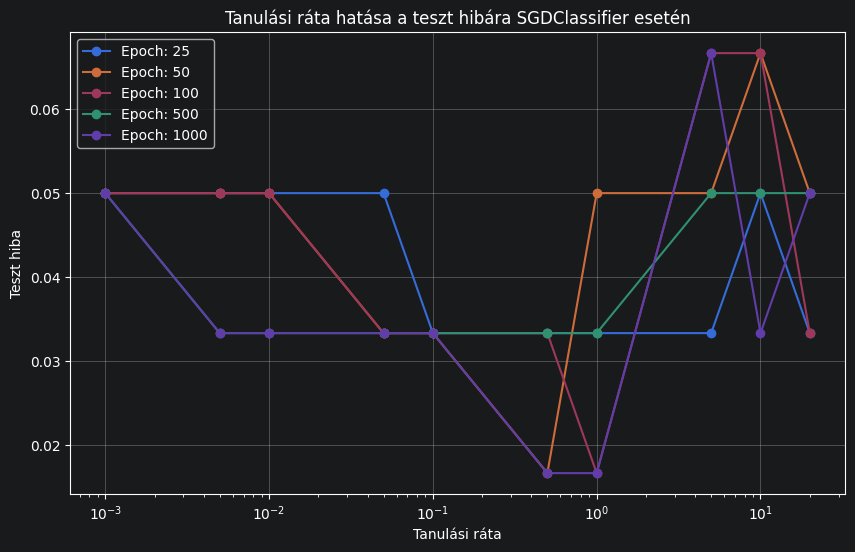

In [97]:
plt.figure(figsize=(10, 6))

for epoch in epochs:
    subset = sgd_tuning_results_df[sgd_tuning_results_df["Epoch"] == epoch]
    plt.plot(
        subset["Learning rate"],
        subset["Teszt hiba"],
        marker="o",
        label=f"Epoch: {epoch}"
    )

plt.xscale("log")
plt.xlabel("Tanulási ráta")
plt.ylabel("Teszt hiba")
plt.title("Tanulási ráta hatása a teszt hibára SGDClassifier esetén")
plt.legend()
plt.grid(True)
plt.show()

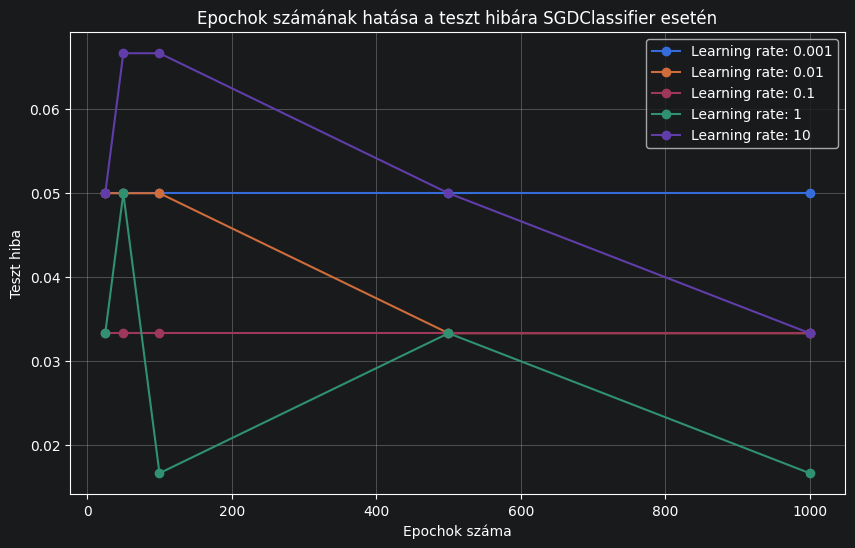

In [98]:
plt.figure(figsize=(10, 6))

for learning_rate in [0.001, 0.01, 0.1, 1, 10]:
    subset = sgd_tuning_results_df[
        sgd_tuning_results_df["Learning rate"] == learning_rate
    ]

    plt.plot(
        subset["Epoch"],
        subset["Teszt hiba"],
        marker="o",
        label=f"Learning rate: {learning_rate}"
    )

plt.xlabel("Epochok száma")
plt.ylabel("Teszt hiba")
plt.title("Epochok számának hatása a teszt hibára SGDClassifier esetén")
plt.legend()
plt.grid(True)
plt.show()

## 2. rész – Valós adathalmaz: Airfoil Self-Noise

In [99]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
columns = [
    'frequency_hz',
    'attack_angle_deg',
    'chord_length_m',
    'free_stream_velocity_ms',
    'suction_side_displacement_thickness_m',
    'scaled_sound_pressure_db',
]

airfoil_df = pd.read_csv(url, sep='\t', header=None, names=columns)
airfoil_df.head()

,frequency_hz,attack_angle_deg,chord_length_m,free_stream_velocity_ms,suction_side_displacement_thickness_m,scaled_sound_pressure_db
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [100]:
print("Adathalmaz mérete:", airfoil_df.shape)
print('Sorok száma:', airfoil_df.shape[0])
print('Oszlopok száma:', airfoil_df.shape[1])
print('Hiányzó értékek száma:')
print(airfoil_df.isna().sum())

print("\nOszlopok és adattípusok:")
print(airfoil_df.dtypes)

print("\nLeíró statisztika:")
display(airfoil_df.describe())

Adathalmaz mérete: (1503, 6)
Sorok száma: 1503
Oszlopok száma: 6
Hiányzó értékek száma:
frequency_hz                             0
attack_angle_deg                         0
chord_length_m                           0
free_stream_velocity_ms                  0
suction_side_displacement_thickness_m    0
scaled_sound_pressure_db                 0
dtype: int64

Oszlopok és adattípusok:
frequency_hz                               int64
attack_angle_deg                         float64
chord_length_m                           float64
free_stream_velocity_ms                  float64
suction_side_displacement_thickness_m    float64
scaled_sound_pressure_db                 float64
dtype: object

Leíró statisztika:


,frequency_hz,attack_angle_deg,chord_length_m,free_stream_velocity_ms,suction_side_displacement_thickness_m,scaled_sound_pressure_db
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


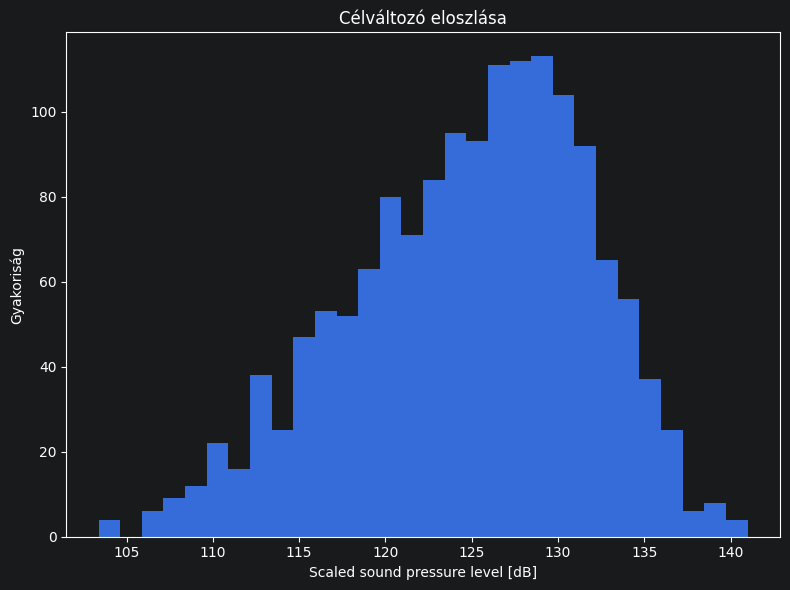

In [101]:
plt.figure(figsize=(8, 6))
plt.hist(airfoil_df['scaled_sound_pressure_db'], bins=30)
plt.xlabel('Scaled sound pressure level [dB]')
plt.ylabel('Gyakoriság')
plt.title('Célváltozó eloszlása')
plt.tight_layout()
plt.show()

### Regressziós modellek összehasonlítása

In [102]:
X_reg = airfoil_df.drop(columns=["scaled_sound_pressure_db"])
y_reg = airfoil_df["scaled_sound_pressure_db"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=RANDOM_STATE
)

regression_models = {
    "Linear Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        {}
    ),

    "Ridge Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        {
            "model__alpha": [0.01, 0.1, 1, 10, 100]
        }
    ),

    "K-Nearest Neighbors Regressor": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor())
        ]),
        {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"]
        }
    ),

    "Random Forest Regressor": (
        RandomForestRegressor(random_state=RANDOM_STATE),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5]
        }
    ),
}

regression_results = []
best_regression_models = {}

for name, (model, params) in regression_models.items():
    print(f"Tanítás: {name}")

    start = time.perf_counter()

    if params:
        grid = GridSearchCV(
            estimator=model,
            param_grid=params,
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=1,              # fontos: hibakeresésnél ne legyen párhuzamos futás
            error_score="raise"
        )

        grid.fit(X_train_reg, y_train_reg)

        best_model = grid.best_estimator_
        best_params = grid.best_params_
    else:
        model.fit(X_train_reg, y_train_reg)

        best_model = model
        best_params = {}

    fit_time = time.perf_counter() - start

    train_pred = best_model.predict(X_train_reg)
    test_pred = best_model.predict(X_test_reg)

    # Extra biztonsági ellenőrzés
    if not np.all(np.isfinite(train_pred)):
        raise ValueError(f"{name} tanítási predikciója NaN vagy inf értéket tartalmaz.")

    if not np.all(np.isfinite(test_pred)):
        raise ValueError(f"{name} teszt predikciója NaN vagy inf értéket tartalmaz.")

    best_regression_models[name] = best_model

    regression_results.append({
        "Algoritmus": name,
        "Tanítási MSE": mean_squared_error(y_train_reg, train_pred),
        "Teszt MSE": mean_squared_error(y_test_reg, test_pred),
        "Tanítási RMSE": np.sqrt(mean_squared_error(y_train_reg, train_pred)),
        "Teszt RMSE": np.sqrt(mean_squared_error(y_test_reg, test_pred)),
        "Tanítási MAE": mean_absolute_error(y_train_reg, train_pred),
        "Teszt MAE": mean_absolute_error(y_test_reg, test_pred),
        "Tanítási R2": r2_score(y_train_reg, train_pred),
        "Teszt R2": r2_score(y_test_reg, test_pred),
        "Tanítási idő [s]": fit_time,
        "Legjobb paraméterek": best_params,
    })

regression_results_df = pd.DataFrame(regression_results)

regression_results_df = regression_results_df.sort_values(
    by="Teszt MSE",
    ascending=True
).reset_index(drop=True)

regression_results_df

Tanítás: Linear Regression
Tanítás: Ridge Regression
Tanítás: K-Nearest Neighbors Regressor
Tanítás: Random Forest Regressor


,Algoritmus,Tanítási MSE,Teszt MSE,Tanítási RMSE,Teszt RMSE,Tanítási MAE,Teszt MAE,Tanítási R2,Teszt R2,Tanítási idő [s],Legjobb paraméterek
0,Random Forest Regressor,0.406903,3.745828,0.63789,1.935414,0.462399,1.400188,0.991280,0.925422,10.393528,"{'max_depth': None, 'min_samples_split': 2, 'n..."
1,K-Nearest Neighbors Regressor,0.000000,6.402694,0.00000,2.530354,0.000000,1.846736,1.000000,0.872524,0.130785,"{'model__n_neighbors': 3, 'model__weights': 'd..."
2,Linear Regression,21.985975,26.383853,4.68892,5.136521,3.663199,3.988916,0.528812,0.474706,0.001760,{}
3,Ridge Regression,21.991130,26.471693,4.68947,5.145065,3.669370,4.005158,0.528702,0.472957,0.053660,{'model__alpha': 10}


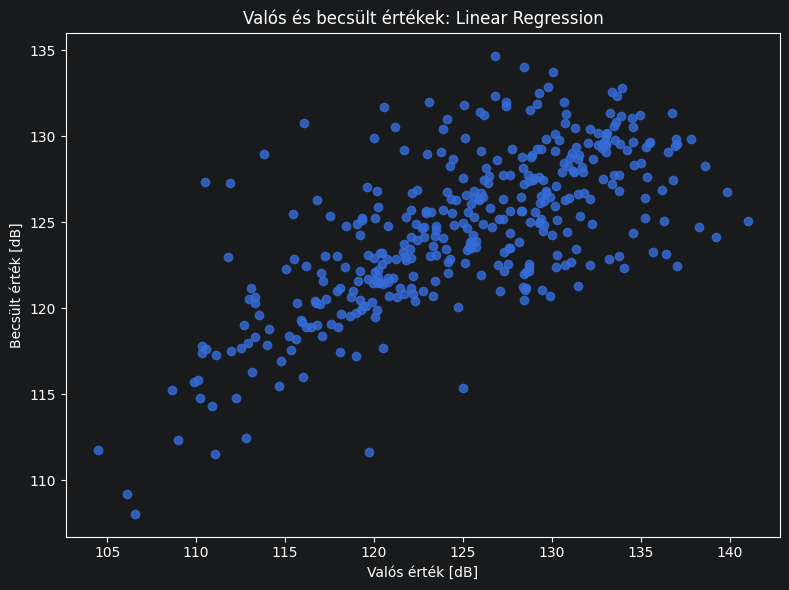

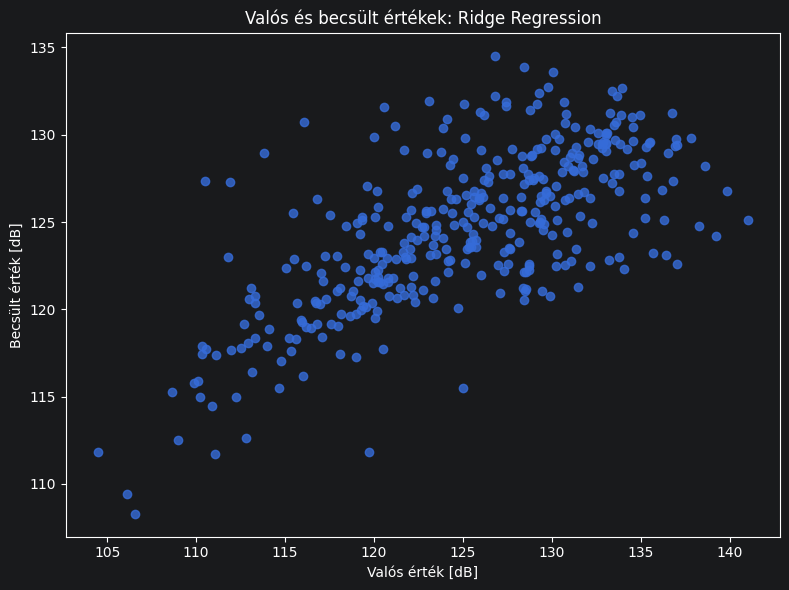

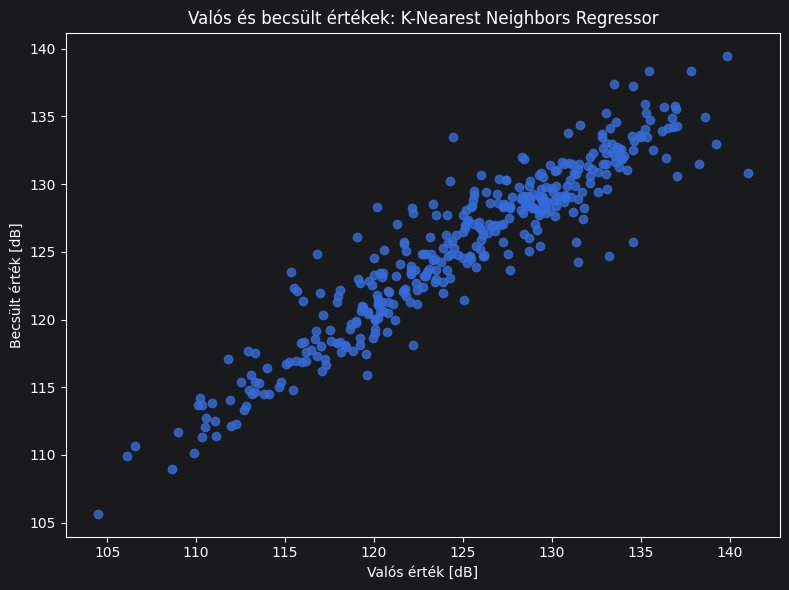

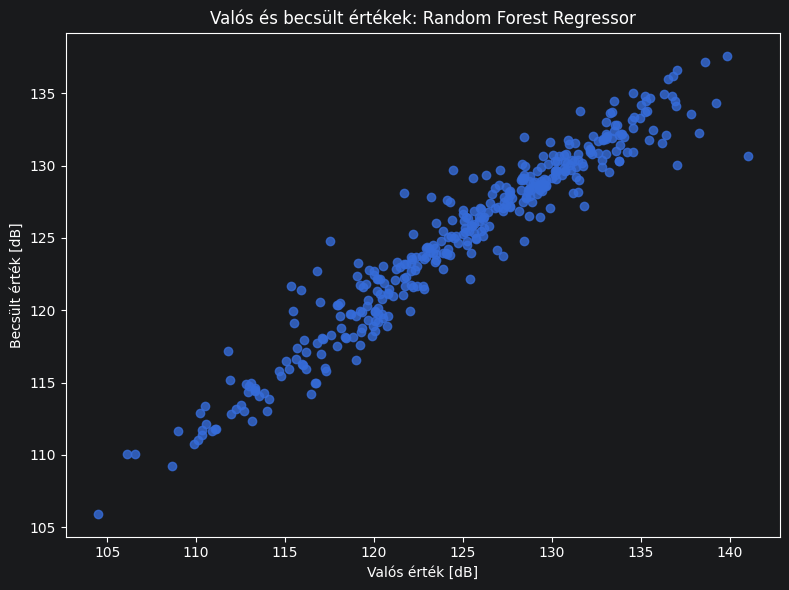

In [103]:
for name, model in best_regression_models.items():
    pred = model.predict(X_test_reg)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_reg, pred, alpha=0.8)
    plt.xlabel('Valós érték [dB]')
    plt.ylabel('Becsült érték [dB]')
    plt.title(f'Valós és becsült értékek: {name}')
    plt.tight_layout()
    plt.show()